# 03 - Evaluación de Modelos

Evaluación comparativa detallada, análisis de métricas e interpretación de resultados de los modelos entrenados.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib

from sklearn.metrics import (classification_report, confusion_matrix, 
                           precision_recall_curve, average_precision_score,
                           matthews_corrcoef, cohen_kappa_score)

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from data_preprocessing import load_processed_data
from model_evaluation import (load_all_models, create_confusion_matrix_plot,
                              calculate_advanced_metrics, generate_evaluation_report)

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

## 1. Carga de Datos y Modelos

In [15]:
# Cargar datos
df = load_processed_data()

# Separar features y target
X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

In [16]:
# Cargar scaler y encoders
models_dir = os.path.join(os.path.dirname(os.getcwd()), 'models')
scaler = joblib.load(os.path.join(models_dir, 'scaler.joblib'))
encoders = joblib.load(os.path.join(models_dir, 'encoders.joblib'))

# Codificar features
from data_preprocessing import encode_categorical_features
X_encoded, _ = encode_categorical_features(X)
X_scaled = scaler.transform(X_encoded)

Columnas codificadas: 16


In [17]:
# Cargar todos los modelos entrenados
trained_models_dir = os.path.join(models_dir, 'trained_models')
models = load_all_models(trained_models_dir)

print(f"Modelos cargados: {list(models.keys())}")

Cargado: Decision Tree
Cargado: Gradient Boosting
Cargado: Knn
Cargado: Logistic Regression
Cargado: Naive Bayes
Cargado: Random Forest
Cargado: Svm
Modelos cargados: ['Decision Tree', 'Gradient Boosting', 'Knn', 'Logistic Regression', 'Naive Bayes', 'Random Forest', 'Svm']


## 2. Matrices de Confusión

In [18]:
# Dividir datos para evaluación
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

c:\Users\dpere\OneDrive\Desktop\pplcdd\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\dpere\OneDrive\Desktop\pplcdd\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


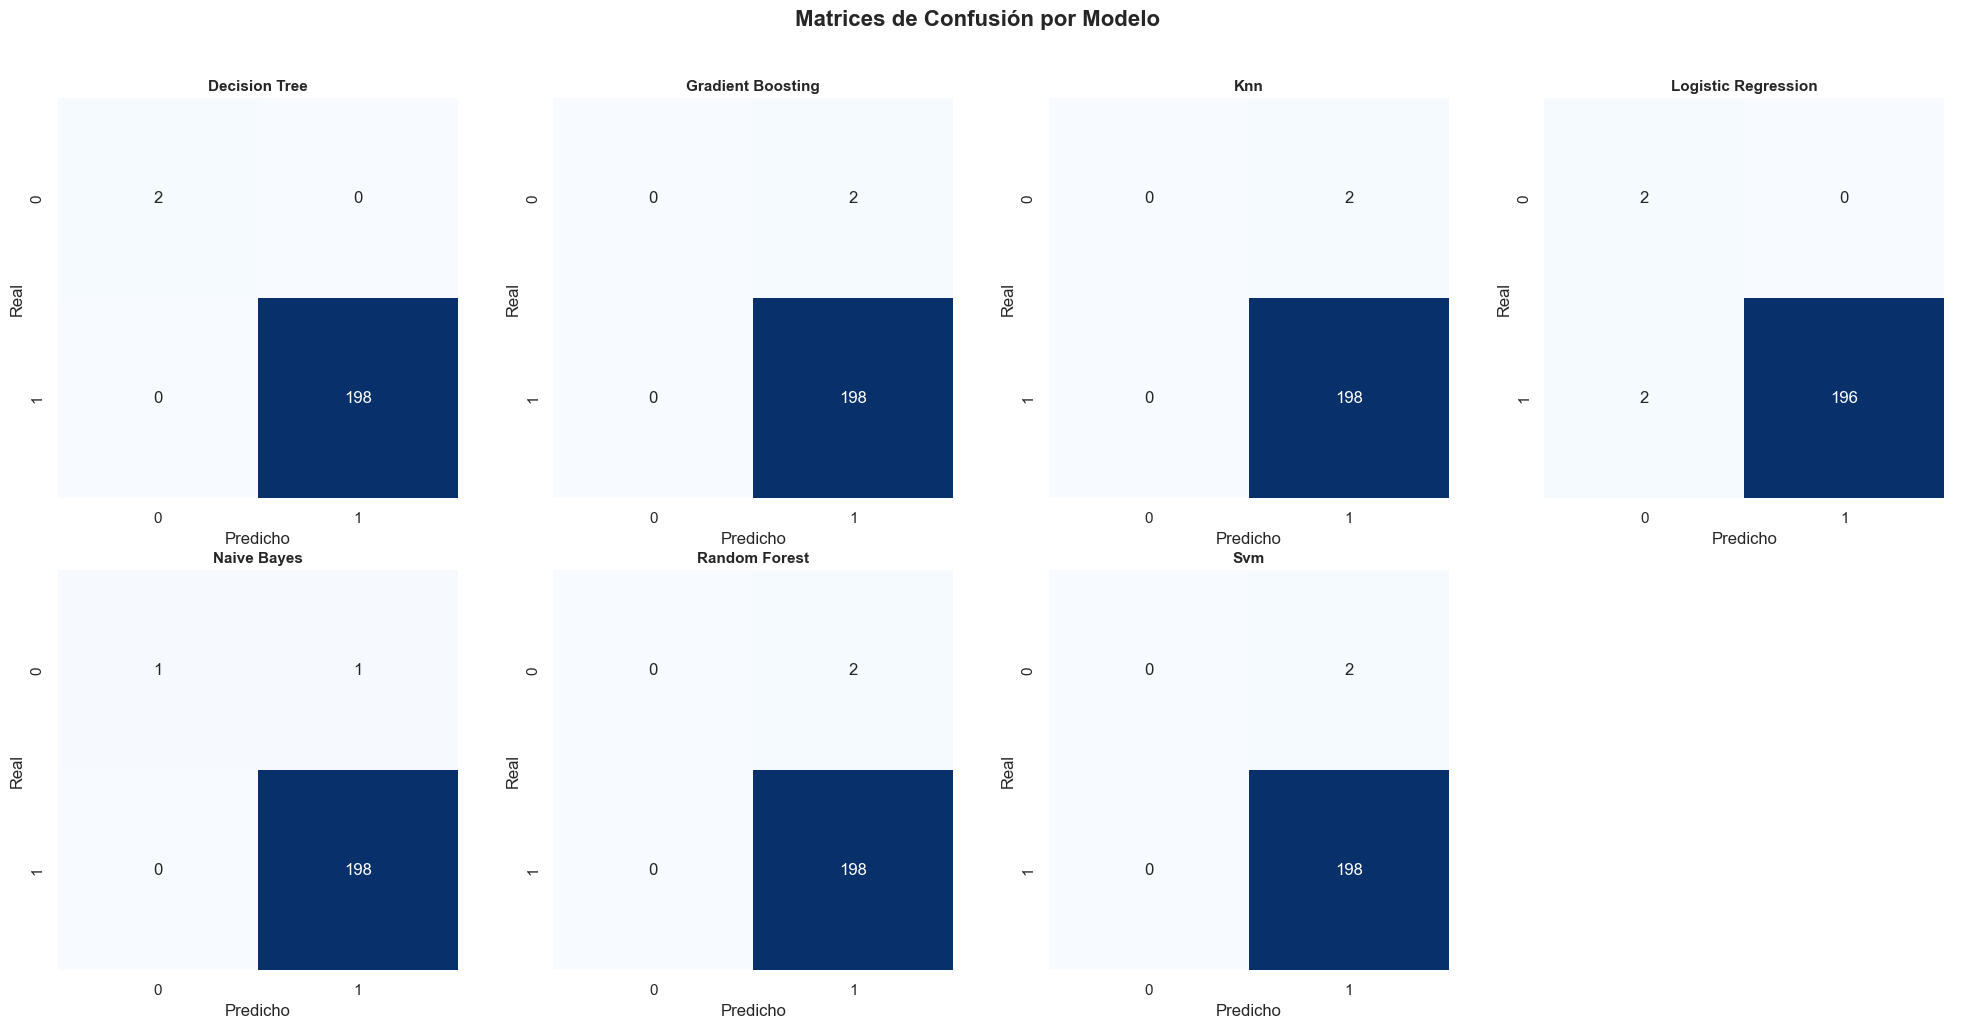

In [19]:
# Crear matrices de confusión para cada modelo
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    if idx < len(axes):
        # Seleccionar datos apropiados
        if name in ['SVM', 'KNN', 'Naive Bayes']:
            X_eval = X_test_scaled
        else:
            X_eval = X_test
        
        # Predicciones
        y_pred = model.predict(X_eval)
        
        # Matriz de confusión
        cm = confusion_matrix(y_test, y_pred)
        
        # Visualizar
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                   cbar=False, square=True)
        axes[idx].set_title(f'{name}', fontweight='bold', fontsize=11)
        axes[idx].set_xlabel('Predicho')
        axes[idx].set_ylabel('Real')

# Ocultar subplot vacío si existe
if len(models) < len(axes):
    axes[-1].axis('off')

plt.suptitle('Matrices de Confusión por Modelo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plots_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'plots')
plt.savefig(os.path.join(plots_dir, '14_confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

## 3. Métricas Avanzadas

In [20]:
# Calcular métricas avanzadas para cada modelo
advanced_metrics = {}

for name, model in models.items():
    # Seleccionar datos
    if name in ['SVM', 'KNN', 'Naive Bayes']:
        X_eval = X_test_scaled
    else:
        X_eval = X_test
    
    y_pred = model.predict(X_eval)
    
    # Calcular métricas
    metrics = calculate_advanced_metrics(y_test, y_pred)
    advanced_metrics[name] = metrics

# Convertir a DataFrame
advanced_df = pd.DataFrame(advanced_metrics).T
advanced_df = advanced_df.round(4)

print("Métricas Avanzadas:")
print(advanced_df.to_string())

Métricas Avanzadas:
                     Accuracy  Precision  Recall  F1-Score  Matthews_Correlation  Cohen_Kappa
Decision Tree           1.000      1.000  1.0000    1.0000                1.0000       1.0000
Gradient Boosting       0.990      0.990  1.0000    0.9950                0.0000       0.0000
Knn                     0.990      0.990  1.0000    0.9950                0.0000       0.0000
Logistic Regression     0.990      1.000  0.9899    0.9949                0.7035       0.6622
Naive Bayes             0.995      0.995  1.0000    0.9975                0.7053       0.6644
Random Forest           0.990      0.990  1.0000    0.9950                0.0000       0.0000
Svm                     0.990      0.990  1.0000    0.9950                0.0000       0.0000


c:\Users\dpere\OneDrive\Desktop\pplcdd\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\dpere\OneDrive\Desktop\pplcdd\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [21]:
# Guardar métricas avanzadas
metrics_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'metrics')
advanced_path = os.path.join(metrics_dir, 'advanced_metrics.csv')
advanced_df.to_csv(advanced_path)
print(f"\nMétricas guardadas: {advanced_path}")


Métricas guardadas: c:\Users\dpere\OneDrive\Desktop\pplcdd\results\metrics\advanced_metrics.csv


## 4. Análisis de Precision-Recall

c:\Users\dpere\OneDrive\Desktop\pplcdd\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\dpere\OneDrive\Desktop\pplcdd\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


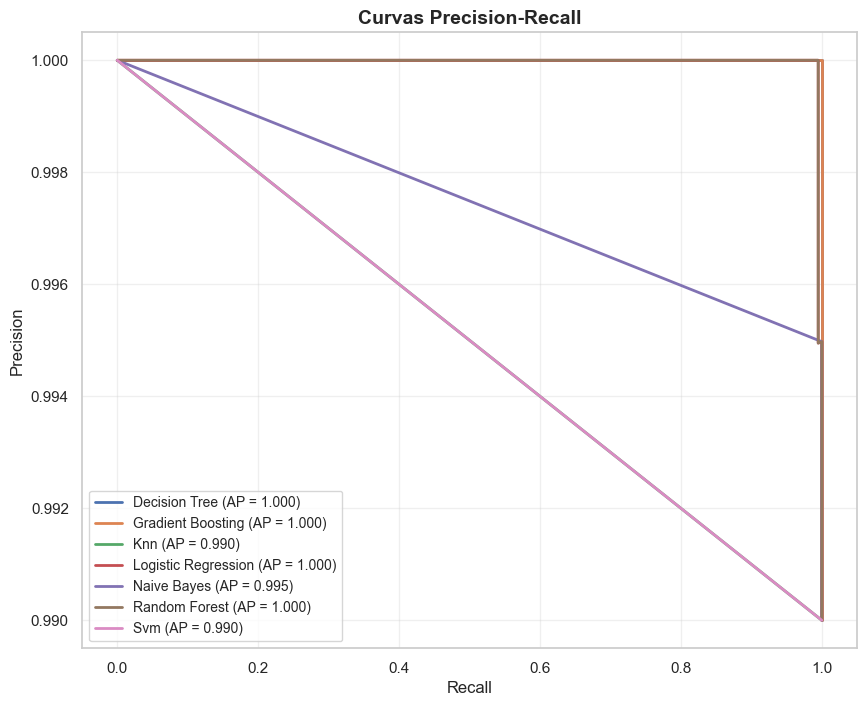

In [22]:
# Curvas Precision-Recall
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Seleccionar datos
    if name in ['SVM', 'KNN', 'Naive Bayes']:
        X_eval = X_test_scaled
    else:
        X_eval = X_test
    
    # Obtener probabilidades
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_eval)[:, 1]
    else:
        continue  # Saltar si no tiene predict_proba
    
    # Calcular curva PR
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})', linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Curvas Precision-Recall', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)

plt.savefig(os.path.join(plots_dir, '15_precision_recall_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. Importancia de Características (Modelos de Árbol)

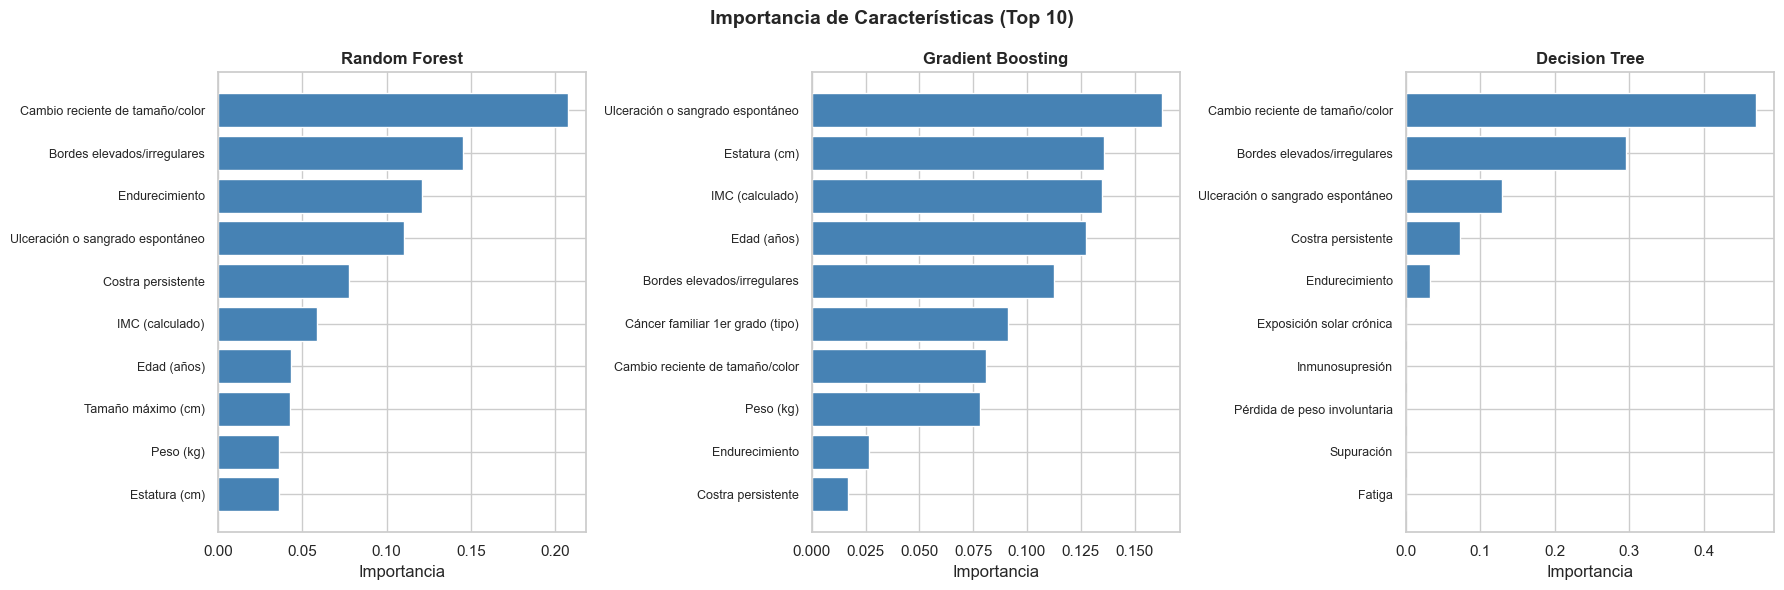

In [23]:
# Visualizar importancia de características para Random Forest y Gradient Boosting
tree_models = ['Random Forest', 'Gradient Boosting', 'Decision Tree']
feature_names = list(X_encoded.columns)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, model_name in enumerate(tree_models):
    if model_name in models:
        model = models[model_name]
        
        # Obtener importancia
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:10]  # Top 10
        
        # Plot
        axes[idx].barh(range(len(indices)), importances[indices], color='steelblue')
        axes[idx].set_yticks(range(len(indices)))
        axes[idx].set_yticklabels([feature_names[i] for i in indices], fontsize=9)
        axes[idx].set_xlabel('Importancia')
        axes[idx].set_title(f'{model_name}', fontweight='bold')
        axes[idx].invert_yaxis()

plt.suptitle('Importancia de Características (Top 10)', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(plots_dir, '16_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Ranking de Modelos

In [24]:
# Cargar resultados del notebook anterior
metrics_path = os.path.join(metrics_dir, 'model_comparison_results.csv')
results_df = pd.read_csv(metrics_path, index_col=0)

# Combinar con métricas avanzadas usando sufijos para distinguir columnas
combined_results = results_df.join(advanced_df, lsuffix='_Basic', rsuffix='_Advanced')

# Ranking por F1-Score (usando la versión de métricas avanzadas)
ranking = combined_results.sort_values('F1-Score_Advanced', ascending=False)

print("Ranking de Modelos (por F1-Score Advanced):")
print(ranking.to_string())

Ranking de Modelos (por F1-Score Advanced):
                     Accuracy_Basic  Precision_Basic  Recall_Basic  F1-Score_Basic  ROC-AUC  Accuracy_Advanced  Precision_Advanced  Recall_Advanced  F1-Score_Advanced  Matthews_Correlation  Cohen_Kappa
Decision Tree                 1.000            1.000        1.0000          1.0000   1.0000              1.000               1.000           1.0000             1.0000                1.0000       1.0000
Naive Bayes                   0.995            0.995        1.0000          0.9975   0.7500              0.995               0.995           1.0000             0.9975                0.7053       0.6644
Random Forest                 0.990            0.990        1.0000          0.9950   0.5000              0.990               0.990           1.0000             0.9950                0.0000       0.0000
Gradient Boosting             0.990            0.990        1.0000          0.9950   0.5000              0.990               0.990           1.0000 

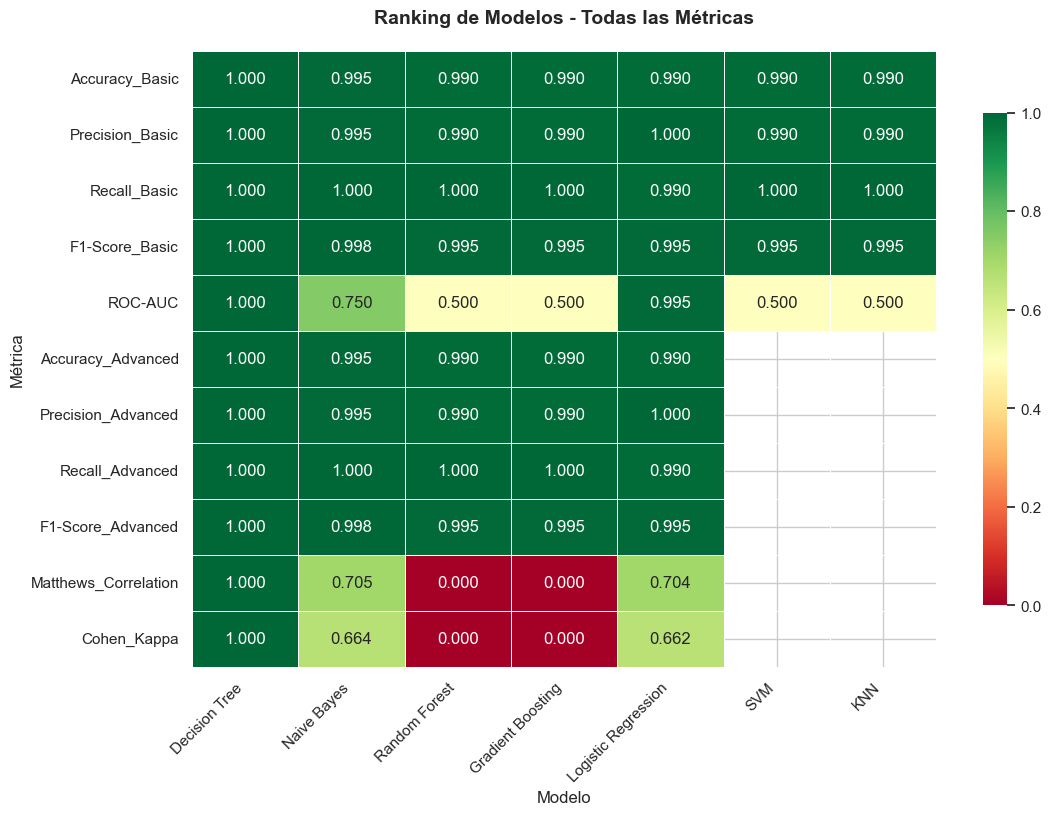

In [25]:
# Visualizar ranking
plt.figure(figsize=(12, 8))

# Heatmap de todas las métricas combinadas
sns.heatmap(ranking.T, annot=True, cmap='RdYlGn', center=0.5,
          fmt='.3f', linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Ranking de Modelos - Todas las Métricas', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Modelo')
plt.ylabel('Métrica')
plt.xticks(rotation=45, ha='right')

plt.savefig(os.path.join(plots_dir, '17_model_ranking_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

## 7. Reporte de Evaluación

In [26]:
# Generar reporte completo
reports_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'reports')
report_path = os.path.join(reports_dir, 'model_evaluation_report.txt')

with open(report_path, 'w') as f:
    f.write('='*60 + '\n')
    f.write('REPORTE DE EVALUACIÓN DE MODELOS\n')
    f.write('='*60 + '\n\n')
    
    f.write('1. RANKING DE MODELOS (por F1-Score):\n')
    f.write('-'*40 + '\n')
    for idx, (model, row) in enumerate(ranking.iterrows(), 1):
        f.write(f"{idx}. {model}: F1={row['F1-Score_Advanced']:.4f}\n")
    
    f.write('\n\n2. MÉTRICAS DETALLADAS:\n')
    f.write('-'*40 + '\n')
    f.write(ranking.to_string())
    
    f.write('\n\n3. OBSERVACIONES:\n')
    f.write('-'*40 + '\n')
    f.write('- El target está extremadamente desbalanceado (99% clase 1)\n')
    f.write('- Métricas como accuracy pueden ser engañosas en este contexto\n')
    f.write('- Se recomienda priorizar F1-Score y AUC para evaluación\n')
    f.write('- Considerar técnicas de balanceo para futuros experimentos\n')

print(f"Reporte guardado: {report_path}")

Reporte guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\results\reports\model_evaluation_report.txt


## Resumen de Evaluación

### Hallazgos principales:

1. **Desbalance extremo**: El 99% de los casos tienen signos de alarma, lo que dificulta el aprendizaje de patrones de la clase minoritaria

2. **Métricas clave**: Dado el desbalance, F1-Score y ROC-AUC son más informativas que accuracy

3. **Interpretación de resultados**:
   - Los modelos pueden alcanzar alta accuracy simplemente prediciendo la clase mayoritaria
   - Se requiere análisis de precision, recall y curvas PR para evaluación justa

### Próximo paso:
Continuar con `04_hyperparameter_optimization.ipynb` para optimizar los mejores modelos.